Beginning analytical solution using NumPy's linear algebra functions...
Computing eigenvalues and eigenvectors...
Eigenvalues: [-2.00000000e-02+0.j         -1.00000000e-02+0.j
 -1.00000000e-02+0.j         -1.46074334e+01+0.j
 -9.33116752e+00+0.j         -1.94115250e-02+0.j
 -3.93198759e+00+0.j         -6.00000000e-02+0.33406586j
 -6.00000000e-02-0.33406586j]


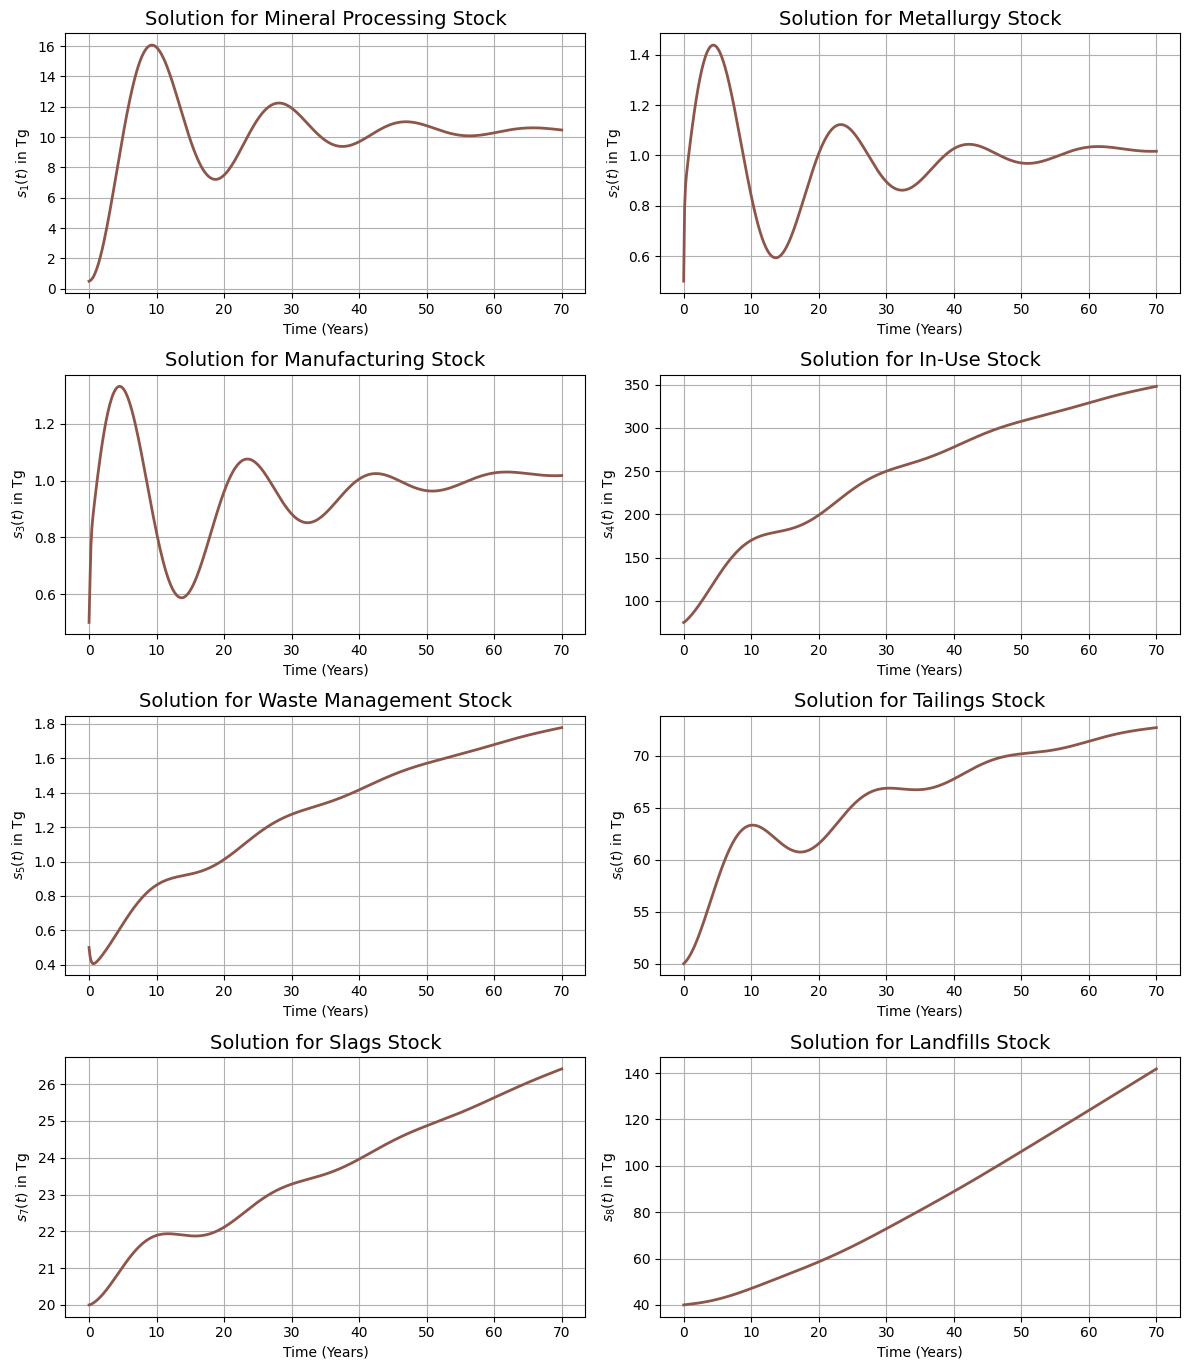

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def solve_and_plot_ode_system_analytical():
    """
    Solves a 9x9 non-homogenous linear system of ODEs analytically
    using NumPy to compute eigenvalues and eigenvectors.
    """

    print("Beginning analytical solution using NumPy's linear algebra functions...")

    # --- 1. Define Numerical Parameters and Matrices ---
    a = 2.5  #3
    beta = 0.2 #0.2
    gamma = 0.6 #0.6
    rho = 1  #1
    b = 0.6  #0.6
    c = 0.15
    alpha2 = 11.20
    alpha3 = 0.60
    alpha5 = 0.01
    alpha6 = 0.33
    alpha7 = 0
    alpha8 = 11.80
    alpha9 = 0.02
    alpha10 = 0
    alpha11 = 1.80
    alpha12 = 0
    alpha13 = 0.70
    alpha14 = 1.40
    alpha15 = 0.01
    alpha16 = 0.01
    alpha17 = 0.01
    alpha18 = 0.01
    alpha19 = 0.01
    alpha20 = 0.01
    alpha21 = 0.01
    alpha22 = 0.01

    # Coefficient Matrix A
    A_matrix = np.array([
        [-gamma * (1 - (beta * rho) / (1 - b - c)), -beta * gamma * (1 - (alpha15 * rho) / (1 - b - c)), 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0],
        [b / (1 - b - c), (b * alpha15) / (1 - b - c), -alpha2 - alpha6 - alpha16, alpha3, 0, alpha14, 0, alpha7, 0], ##
        [0, 0, alpha2, -alpha3 - alpha8 - alpha10 - alpha17, 0, alpha13, 0, 0, 0],
        [0, 0, 0, alpha8, -alpha9 - alpha18, 0, 0, 0, 0],
        [0, 0, 0, alpha10, alpha9, -alpha11 - alpha13 - alpha14 - alpha19, 0, 0, alpha12],
        [c / (1 - b - c), (c * alpha15) / (1 - b - c), 0, 0, 0, 0, -alpha5 - alpha20, 0, 0],
        [0, 0, alpha6, 0, 0, 0, 0, -alpha7 - alpha21, 0],
        [0, 0, 0, 0, 0, alpha11, 0, 0, -alpha12 - alpha22]
    ])

    # Non-homogeneous vector b
    b_vector = np.array([
        (a * beta * gamma * rho) / (1 - b - c),
        0,
        a * (1 + b / (1 - b - c)),
        0,
        0,
        0,
        (a * c) / (1 - b - c),
        0,
        0
    ])

    # Initial conditions
    x0 = np.array([0.1, 0.5, 0.5, 0.5, 75, 0.50, 50, 20, 40])

    # --- 2. Find Eigenvalues and Eigenvectors ---
    print("Computing eigenvalues and eigenvectors...")
    eigenvalues, eigenvectors = np.linalg.eig(A_matrix)
    print("Eigenvalues:", eigenvalues)
    # --- 3. Calculate the Particular Solution ---
    y_p = -np.linalg.solve(A_matrix, b_vector)

    # --- 4. Solve for the Coefficients (c_i) ---
    c = np.linalg.solve(eigenvectors, x0 - y_p)

    # --- 5. Define the Analytical Solution Function ---
    def analytical_solution(t):
        """
        Constructs and evaluates the complete analytical solution at time t.
        """
        y_homogeneous = np.sum(
            [c[i] * eigenvectors[:, i] * np.exp(eigenvalues[i] * t)
             for i in range(len(eigenvalues))], axis=0
        )
        return np.real(y_homogeneous + y_p)

    # --- 6. Plotting the Solutions ---
    t_eval = np.linspace(0, 70, 500)
    y_analytical = np.array([analytical_solution(t) for t in t_eval])

    plt.style.use('default')

    # Create a 2x4 grid for the 8 plots
    fig, axes = plt.subplots(4, 2, figsize=(12, 15))

    axes = axes.flatten()

    # Plot variables s1 to s8 (indices 1 to 8 in the y_analytical array)
    for i in range(8): # Iterate 8 times for s1 to s8
        axes[i].plot(t_eval, y_analytical[:, i+1], 'tab:brown', label=f's{i+1}(t)', linewidth=2)
        if i+1 == 1:
          axes[i].set_title(f'Solution for Mineral Processing Stock', fontsize=14)
        elif i+1 == 2:
          axes[i].set_title(f'Solution for Metallurgy Stock', fontsize=14)
        elif i+1 == 3:
          axes[i].set_title(f'Solution for Manufacturing Stock', fontsize=14)
        elif i+1 == 4:
          axes[i].set_title(f'Solution for In-Use Stock', fontsize=14)
        elif i+1 == 5:
          axes[i].set_title(f'Solution for Waste Management Stock', fontsize=14)
        elif i+1 == 6:
          axes[i].set_title(f'Solution for Tailings Stock', fontsize=14)
        elif i+1 == 7:
          axes[i].set_title(f'Solution for Slags Stock', fontsize=14)
        elif i+1 == 8:
          axes[i].set_title(f'Solution for Landfills Stock', fontsize=14)
        axes[i].set_xlabel('Time (Years)')
        axes[i].set_ylabel(f'$s_{{{i+1}}}(t)$ in Tg')
        axes[i].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

if __name__ == "__main__":
    solve_and_plot_ode_system_analytical()

In [3]:
    # --- 1. Define Numerical Parameters and Matrices ---
a = 2.5  #3
beta = 0.008 #0.008
gamma = 0.6 #0.6
rho = 6  #1
b = 0.8  #0.6
c = 0.15
alpha2 = 11.20
alpha3 = 0.60
alpha5 = 0.01
alpha6 = 0.33
alpha7 = 0.01  #0
alpha8 = 11.80
alpha9 = 0.02
alpha10 = 0.01 #0
alpha11 = 1.80
alpha12 = 0.01 #0
alpha13 = 0.70
alpha14 = 1.40
alpha15 = 0.01
alpha16 = 0.01
alpha17 = 0.01
alpha18 = 0.01
alpha19 = 0.01
alpha20 = 0.01
alpha21 = 0.01
alpha22 = 0.01

    # Coefficient Matrix A
A_matrix = np.array([
        [-gamma * (1 - (beta * rho) / (1 - b - c)), -beta * gamma * (1 - (alpha15 * rho) / (1 - b - c)), 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0],
        [b / (1 - b - c), (b * alpha15) / (1 - b - c), -alpha2 - alpha6 - alpha16, alpha3, 0, alpha14, 0, alpha7, 0], ##
        [0, 0, alpha2, -alpha3 - alpha8 - alpha10 - alpha17, 0, alpha13, 0, 0, 0],
        [0, 0, 0, alpha8, -alpha9 - alpha18, 0, 0, 0, 0],
        [0, 0, 0, alpha10, alpha9, -alpha11 - alpha13 - alpha14 - alpha19, 0, 0, alpha12],
        [c / (1 - b - c), (c * alpha15) / (1 - b - c), 0, 0, 0, 0, -alpha5 - alpha20, 0, 0],
        [0, 0, alpha6, 0, 0, 0, 0, -alpha7 - alpha21, 0],
        [0, 0, 0, 0, 0, alpha11, 0, 0, -alpha12 - alpha22]
    ])

eigenvalues, eigenvectors = np.linalg.eig(A_matrix)
print((1-b-c)/rho)
print("a11", -gamma * (1 - (beta * rho) / (1 - b - c)))
print("a12", -beta * gamma * (1 - (alpha15 * rho) / (1 - b - c)))

0.008333333333333326
a11 -0.023999999999999553
a12 0.0009600000000000039


In [4]:
# Loop to print each eigenvalue with its eigenvector


for i in range(len(eigenvalues)):
    eigval = eigenvalues[i]
    eigvec = np.real(eigenvectors[:, i])  # Real part to handle any tiny imaginary artifacts
    print(f"Eigenvalue {i}: {eigval}")
    print(f"Eigenvector: {eigvec}")
    print("---")  # Separator for readability

Eigenvalue 0: -0.02
Eigenvector: [0. 0. 0. 0. 0. 0. 1. 0. 0.]
---
Eigenvalue 1: -14.610953721873464
Eigenvector: [ 1.47889653e-20  6.63944549e-19 -1.50361876e-01  7.68497304e-01
 -6.21925586e-01  4.44267574e-04 -1.30852991e-20  3.40069746e-03
 -5.48066732e-05]
---
Eigenvalue 2: -9.341596493835302
Eigenvector: [-8.08556735e-23  1.40085677e-18 -1.67742893e-01 -6.10682938e-01
  7.73880040e-01 -1.72584691e-03  3.43134872e-20  5.93837706e-03
  3.33260986e-04]
---
Eigenvalue 3: -3.9329253831475834
Eigenvector: [-1.18451738e-18 -1.69924721e-17  1.32030511e-01  2.25442534e-01
 -6.81596916e-01  6.20865554e-01  1.01492320e-18 -1.11349091e-02
 -2.85606775e-01]
---
Eigenvalue 4: 0.021226495451672135
Eigenvector: [0.00164169 0.07734174 0.00424689 0.00413021 0.95139218 0.00545672
 0.17574462 0.0339945  0.23824736]
---
Eigenvalue 5: -0.045226495451672295
Eigenvector: [-0.00188994  0.04178829 -0.00159486 -0.00121159  0.93893722  0.00409903
  0.17506056  0.02086314 -0.29248038]
---
Eigenvalue 6: -0.010

In [5]:
eigenvalues[4], eigenvectors[:,4]

(np.float64(0.021226495451672135),
 array([0.00164169, 0.07734174, 0.00424689, 0.00413021, 0.95139218,
        0.00545672, 0.17574462, 0.0339945 , 0.23824736]))

Aggregate Erlang scalar delta = 0.03467
Sectoral delta mode = 'loss_plus_abandoned'
Fixed exponential ignores delta_mode and uses alpha9, alpha18 only.


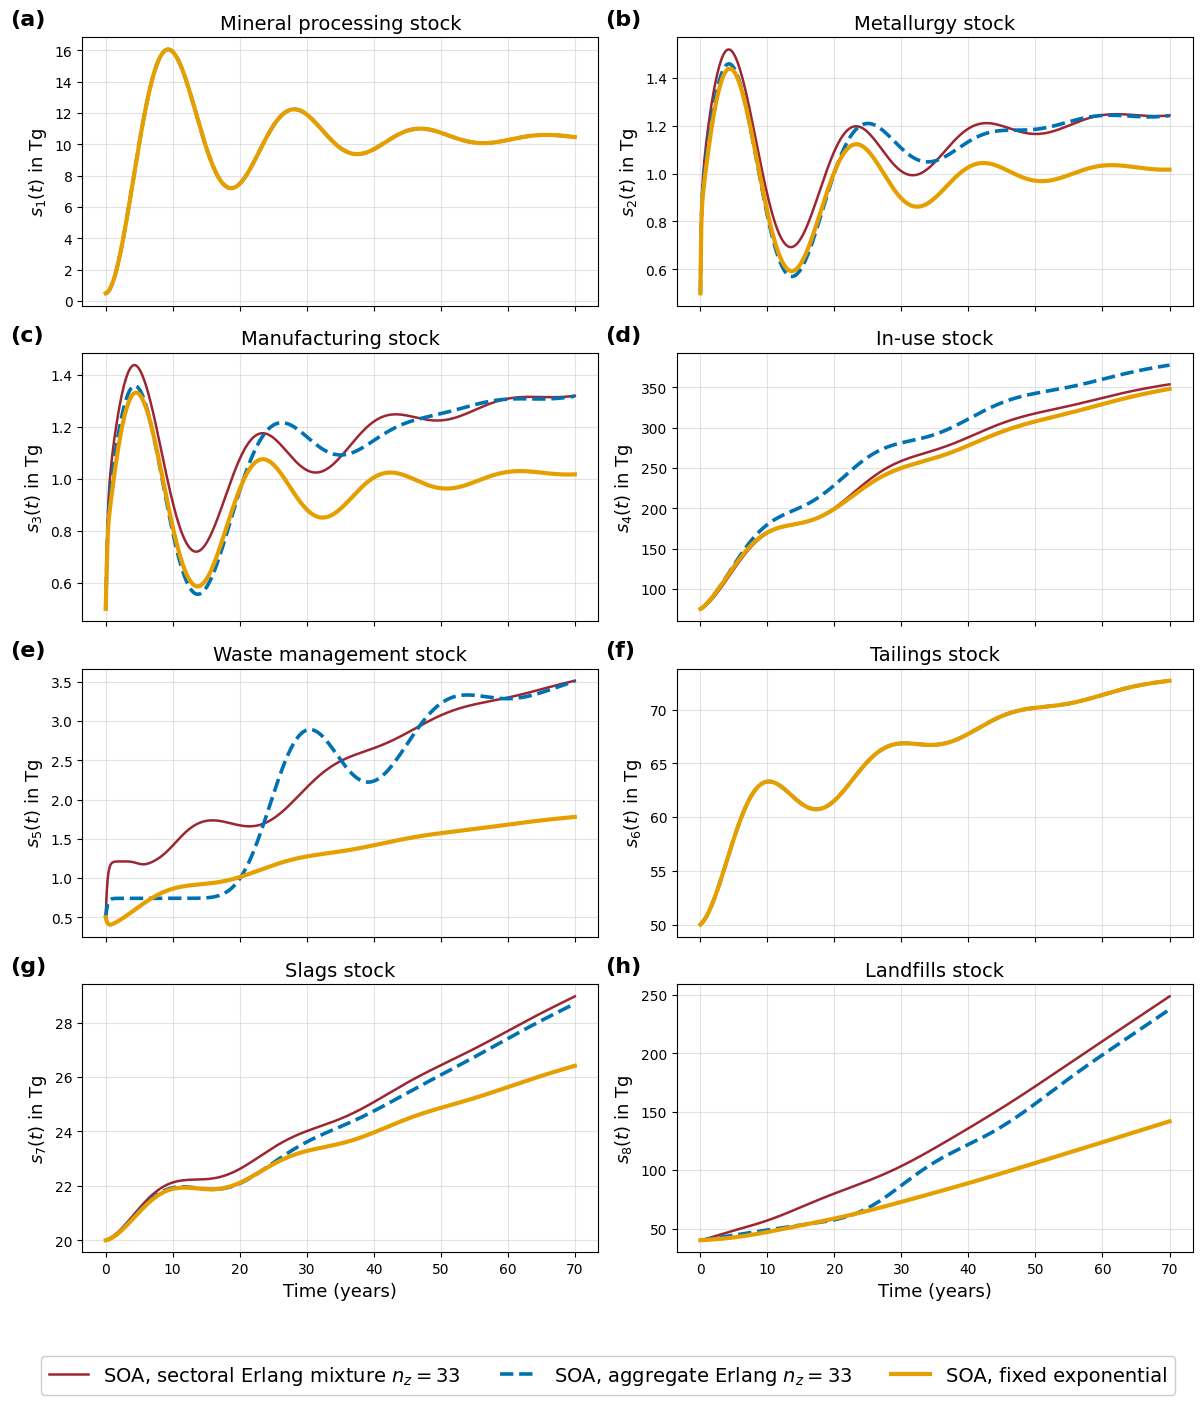

Aggregate Erlang scalar delta = 0.03467
Sectoral delta mode = 'loss_plus_abandoned'
Fixed exponential ignores delta_mode and uses alpha9, alpha18 only.


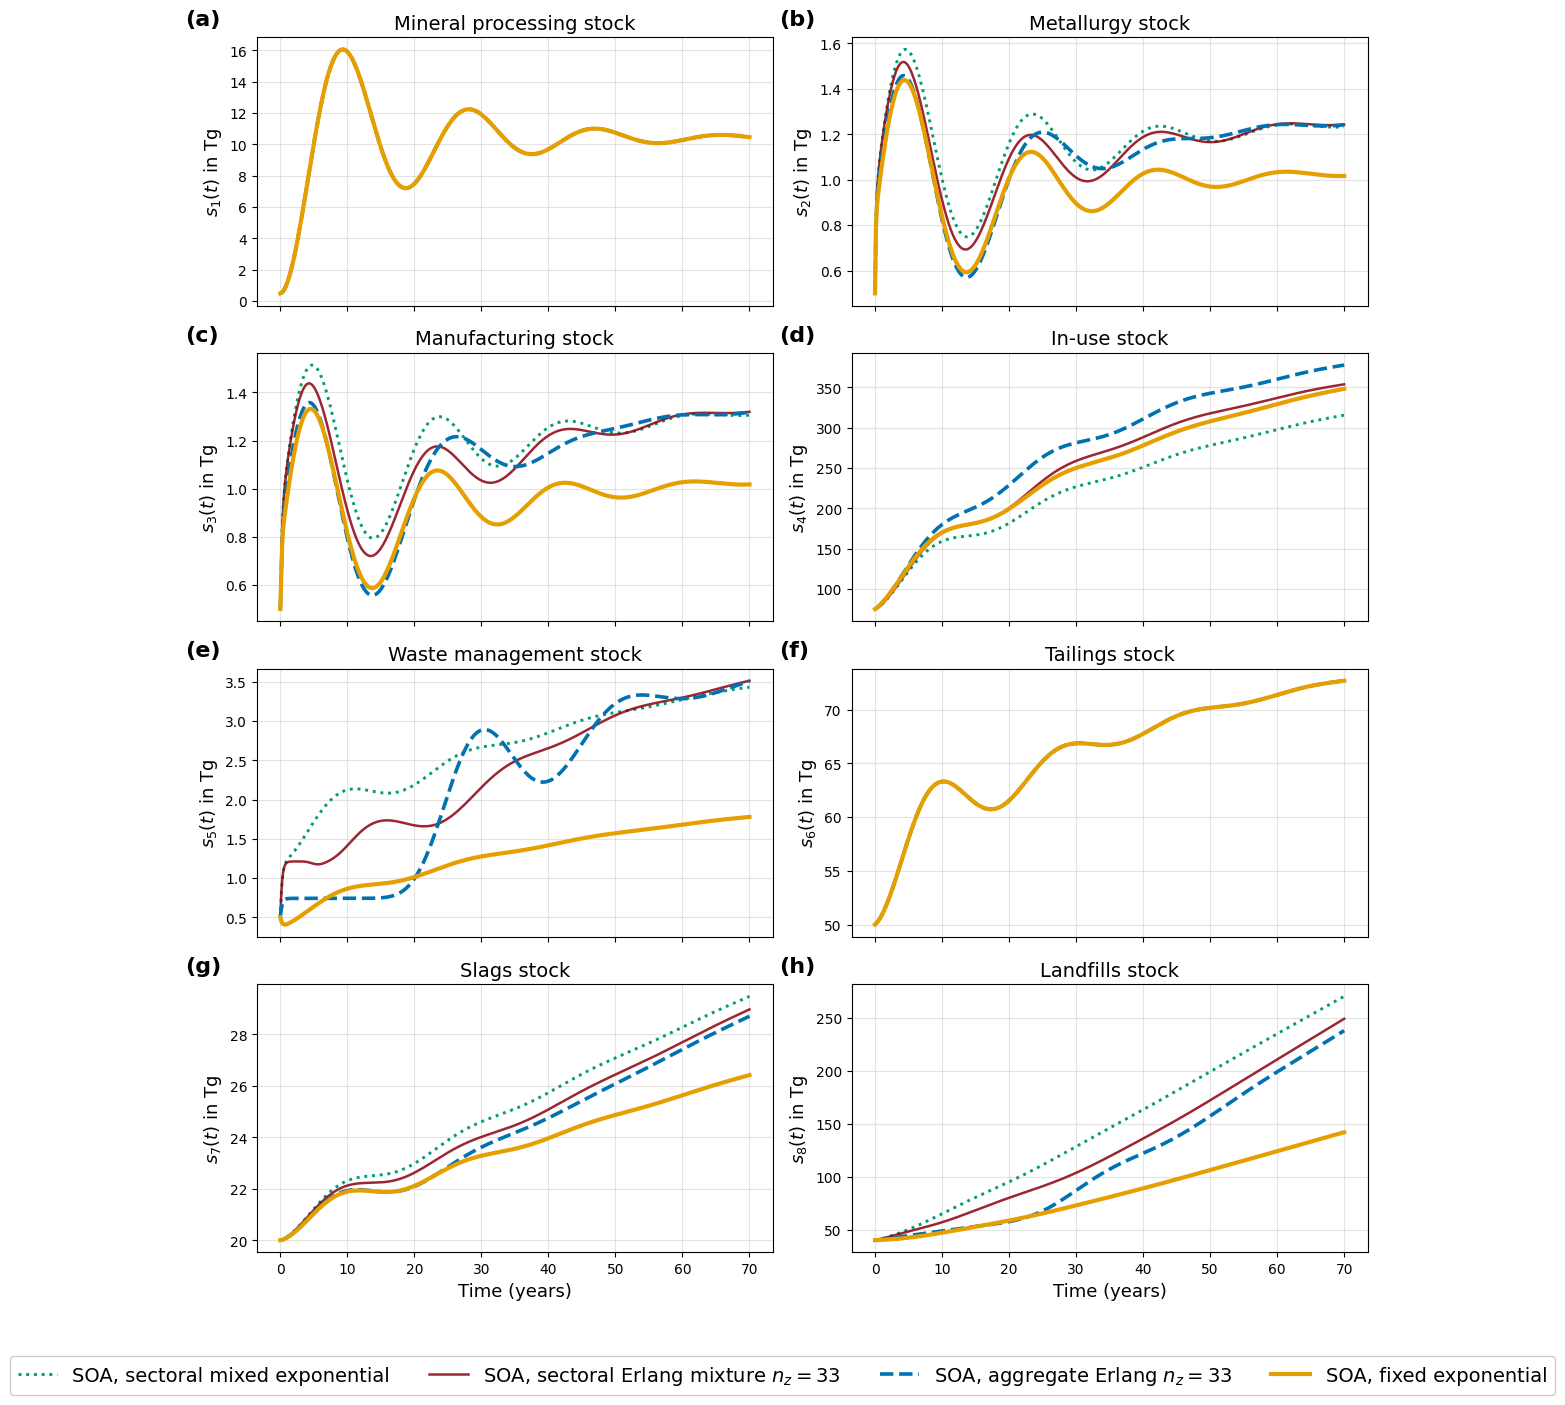

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import expm_multiply


# ============================================================
# 0. Colour and line-style palette
# ============================================================

READY_PALETTE = {
    "Gloser": "#000000",
    "Fixed exponential": "#E69F00",
    "Mixed exponential": "#009E73",
    "Erlang m=5": "#8C000F",
    "Erlang m=33": "#0072B2",
}

READY_LINESTYLES = {
    "Gloser": "-",
    "Fixed exponential": "-",
    "Mixed exponential": ":",
    "Erlang m=5": "-.",
    "Erlang m=33": "--",
}


# ============================================================
# 1. SOA copper parametrisation
# ============================================================

def copper_soa_params():
    """
    SOA parametrisation.
    """
    return dict(
        a=2.5,
        beta=0.2,
        gamma=0.6,
        rho=1.0,
        b=0.6,
        c=0.15,

        alpha2=11.20,
        alpha3=0.60,
        alpha5=0.01,
        alpha6=0.33,
        alpha7=0.0,
        alpha8=11.80,

        # In the Erlang models, alpha9 and alpha18 are not used
        # as independent use-phase hazards. They only define the
        # fixed-exponential baseline rate alpha9 + alpha18 = 0.03.
        alpha9=0.02,
        alpha10=0.0,
        alpha11=1.80,
        alpha12=0.0,
        alpha13=0.70,
        alpha14=1.40,

        alpha15=0.01,
        alpha16=0.01,
        alpha17=0.01,
        alpha18=0.01,
        alpha19=0.01,
        alpha20=0.01,
        alpha21=0.01,
        alpha22=0.01,
    )

# ============================================================
# 2. Analytical matrix-exponential solution
# ============================================================

def solve_linear_ode_matrix_exponential(A, b, x0, t_eval):
    """
    Closed-form solution for

        dx/dt = A x + b

    with constant A and b:

        x(t) = x* + exp(A t) (x0 - x*)
        x*  = -A^{-1} b

    This evaluates the matrix-exponential solution.
    """
    x_star = -np.linalg.solve(A, b)
    z0 = x0 - x_star

    if not np.allclose(t_eval, np.linspace(t_eval[0], t_eval[-1], len(t_eval))):
        raise ValueError("t_eval must be evenly spaced for expm_multiply.")

    Z = expm_multiply(
        csr_matrix(A),
        z0,
        start=float(t_eval[0]),
        stop=float(t_eval[-1]),
        num=len(t_eval),
        endpoint=True,
    )

    return np.real_if_close(Z + x_star)


# ============================================================
# 3. Glöser-style use-phase dissipation shares
# ============================================================

def gloser_loss_abandoned_map():
    """
    Loss and abandoned-in-place shares from Glöser SI Table S5.

    In the default analytical comparison below, delta is interpreted as
    dissipative loss only. Abandoned-in-place can be included by setting
    delta_mode='loss_plus_abandoned'.
    """
    return {
        "Plumbing": {
            "loss_share": 0.01,
            "abandoned_share": 0.04,
        },
        "Building Plant": {
            "loss_share": 0.01,
            "abandoned_share": 0.04,
        },
        "Architecture": {
            "loss_share": 0.01,
            "abandoned_share": 0.00,
        },
        "Communications": {
            "loss_share": 0.01,
            "abandoned_share": 0.05,
        },
        "Electrical Power": {
            "loss_share": 0.01,
            "abandoned_share": 0.00,
        },
        "Telecommunications": {
            "loss_share": 0.01,
            "abandoned_share": 0.05,
        },
        "Power Utility": {
            "loss_share": 0.01,
            "abandoned_share": 0.00,
        },
        "Electrical Industrial": {
            "loss_share": 0.01,
            "abandoned_share": 0.00,
        },
        "Non Electrical Industrial": {
            "loss_share": 0.01,
            "abandoned_share": 0.00,
        },
        "Electrical Automotive": {
            "loss_share": 0.01,
            "abandoned_share": 0.00,
        },
        "Non Electrical Automotive": {
            "loss_share": 0.02,
            "abandoned_share": 0.00,
        },
        "Other Transport": {
            "loss_share": 0.01,
            "abandoned_share": 0.00,
        },
        "Consumer": {
            "loss_share": 0.05,
            "abandoned_share": 0.00,
        },
        "Cooling": {
            "loss_share": 0.01,
            "abandoned_share": 0.00,
        },
        "Electronic": {
            "loss_share": 0.05,
            "abandoned_share": 0.00,
        },
        "Diverse": {
            "loss_share": 0.10,
            "abandoned_share": 0.00,
        },
    }


def add_gloser_use_loss_shares(sector_df, *, delta_mode="loss"):
    """
    Add Glöser-style use-exit routing shares to the sector table.

    Parameters
    ----------
    sector_df : DataFrame
        Must include a 'subsector' column matching the Glöser Table S5 names.

    delta_mode : {"loss", "loss_plus_abandoned"}
        "loss":
            delta is only the dissipative-loss share.

        "loss_plus_abandoned":
            delta is dissipative loss plus abandoned-in-place share.

    Returns
    -------
    DataFrame with columns:
        loss_share
        abandoned_share
        delta
        waste_management_share = 1 - delta
    """
    if delta_mode not in {"loss", "loss_plus_abandoned"}:
        raise ValueError("delta_mode must be 'loss' or 'loss_plus_abandoned'.")

    lookup = gloser_loss_abandoned_map()
    out = sector_df.copy()

    out["loss_share"] = out["subsector"].map(
        lambda x: lookup[x]["loss_share"]
    )

    out["abandoned_share"] = out["subsector"].map(
        lambda x: lookup[x]["abandoned_share"]
    )

    if delta_mode == "loss":
        out["delta"] = out["loss_share"]

    elif delta_mode == "loss_plus_abandoned":
        out["delta"] = out["loss_share"] + out["abandoned_share"]

    out["waste_management_share"] = 1.0 - out["delta"]

    return out


def weighted_gloser_delta(sector_df, *, delta_mode="loss"):
    """
    Compute the weighted average Glöser delta for aggregate models.

    This lets the aggregate Erlang and fixed exponential models use a
    single scalar delta consistent with the sectoral weights.
    """
    sector_df = add_gloser_use_loss_shares(sector_df, delta_mode=delta_mode)

    weights = sector_df["weight"].to_numpy(dtype=float)
    weights = weights / weights.sum()

    delta_values = sector_df["delta"].to_numpy(dtype=float)

    return float(np.sum(weights * delta_values))


# ============================================================
# 4. Build SOA model with exponential or Erlang in-use stock
# ============================================================

def build_soa_use_chain_model(
    params=None,
    *,
    m=1,
    k=None,
    sector_df=None,
    delta=0.0,
    delta_mode="loss",
):
    """
    Build the autonomous SOA model with the in-use stock represented by:

      1. one aggregate exponential/Erlang chain:
           sector_df=None, m stages, common rate k, common delta

      2. a sectoral mixture of Erlang chains:
           sector_df has columns 'weight' and 'tau',
           with m stages per subsector and k_i = m / tau_i.

    Correct convention:

        gross exit from use_i(t) = k_i u_{i,m}(t)

        waste-management inflow_i(t) = (1 - delta_i) k_i u_{i,m}(t)

        dissipation_i(t) = delta_i k_i u_{i,m}(t)

    Therefore:
      - k_i fully parametrises the total in-use residence-time process;
      - alpha_9 is not used as a separate use-phase exit rate;
      - alpha_18 is not used as a separate continuous use-phase hazard.
    """
    p = copper_soa_params() if params is None else params.copy()

    den = 1.0 - p["b"] - p["c"]
    if den <= 0:
        raise ValueError("Need 1 - b - c > 0 for the SOA parametrisation.")

    # --------------------------------------------------------
    # Chain rates, weights and delta values
    # --------------------------------------------------------

    if sector_df is None:
        if k is None:
            # Fixed exponential baseline from the distribution code:
            # alpha_9 + alpha_18 = 0.03.
            #
            # This is treated as the total use-exit rate, not as a
            # separate alpha_9 discard hazard.
            k = p["alpha9"] + p["alpha18"]

        chain_rates = np.array([float(k)])
        chain_weights = np.array([1.0])
        chain_names = ["aggregate"]
        chain_delta = np.array([float(delta)])

    else:
        required = {"weight", "tau"}
        missing = required.difference(sector_df.columns)

        if missing:
            raise ValueError(f"sector_df is missing columns: {missing}")

        sector_df = sector_df.copy()

        if "delta" not in sector_df.columns:
            if "subsector" in sector_df.columns:
                sector_df = add_gloser_use_loss_shares(
                    sector_df,
                    delta_mode=delta_mode,
                )
            else:
                sector_df["delta"] = float(delta)

        chain_weights = sector_df["weight"].to_numpy(dtype=float)
        chain_weights = chain_weights / chain_weights.sum()

        tau = sector_df["tau"].to_numpy(dtype=float)
        chain_rates = m / tau

        chain_delta = sector_df["delta"].to_numpy(dtype=float)

        if np.any(chain_delta < 0) or np.any(chain_delta > 1):
            raise ValueError("All delta values must lie between 0 and 1.")

        if "subsector" in sector_df.columns:
            chain_names = sector_df["subsector"].astype(str).to_list()
        else:
            chain_names = [f"sector_{i + 1}" for i in range(len(chain_weights))]

    n_chains = len(chain_weights)
    n_use_compartments = n_chains * m

    # Base states:
    # v1, s1, s2, s3, s5, s6, s7, s8 = 8 states
    # plus n_use_compartments replacing the original single s4.
    N = 8 + n_use_compartments

    idx_v1 = 0
    idx_s1 = 1
    idx_s2 = 2
    idx_s3 = 3

    idx_use0 = 4
    use_indices = np.arange(idx_use0, idx_use0 + n_use_compartments)

    idx_s5 = idx_use0 + n_use_compartments
    idx_s6 = idx_s5 + 1
    idx_s7 = idx_s5 + 2
    idx_s8 = idx_s5 + 3

    A = np.zeros((N, N), dtype=float)
    bvec = np.zeros(N, dtype=float)

    # --------------------------------------------------------
    # SOA mining / mineral-processing block
    # --------------------------------------------------------

    A[idx_v1, idx_v1] = -p["gamma"] * (
        1.0 - (p["beta"] * p["rho"]) / den
    )

    A[idx_v1, idx_s1] = -p["beta"] * p["gamma"] * (
        1.0 - (p["alpha15"] * p["rho"]) / den
    )

    A[idx_s1, idx_v1] = 1.0

    # --------------------------------------------------------
    # Metallurgy stock, s2
    # --------------------------------------------------------

    A[idx_s2, idx_v1] = p["b"] / den
    A[idx_s2, idx_s1] = (p["b"] * p["alpha15"]) / den

    A[idx_s2, idx_s2] = -p["alpha2"] - p["alpha6"] - p["alpha16"]
    A[idx_s2, idx_s3] = p["alpha3"]
    A[idx_s2, idx_s5] = p["alpha14"]
    A[idx_s2, idx_s7] = p["alpha7"]

    # --------------------------------------------------------
    # Manufacturing stock, s3
    # --------------------------------------------------------

    A[idx_s3, idx_s2] = p["alpha2"]

    A[idx_s3, idx_s3] = (
        -p["alpha3"]
        - p["alpha8"]
        - p["alpha10"]
        - p["alpha17"]
    )

    A[idx_s3, idx_s5] = p["alpha13"]

    # --------------------------------------------------------
    # Corrected in-use Erlang chain(s)
    # --------------------------------------------------------

    for i, (w_i, k_i, delta_i) in enumerate(
        zip(chain_weights, chain_rates, chain_delta)
    ):
        first = idx_use0 + i * m
        last = first + m - 1

        # Product inflow from manufacturing is split across chains.
        A[first, idx_s3] = p["alpha8"] * w_i

        # Serial Erlang stages.
        # The full rate k_i controls the total residence-time process.
        for j in range(m):
            idx = first + j
            A[idx, idx] = -k_i

            if j > 0:
                A[idx, idx - 1] = k_i

        # Final-stage gross output is k_i u_{i,m}.
        # Only the fraction (1 - delta_i) enters waste management.
        # The fraction delta_i leaves as dissipation.
        A[idx_s5, last] = (1.0 - delta_i) * k_i

    # --------------------------------------------------------
    # Waste management stock, s5
    # --------------------------------------------------------

    A[idx_s5, idx_s3] = p["alpha10"]

    A[idx_s5, idx_s5] = (
        -p["alpha11"]
        - p["alpha13"]
        - p["alpha14"]
        - p["alpha19"]
    )

    A[idx_s5, idx_s8] = p["alpha12"]

    # --------------------------------------------------------
    # Tailings stock, s6
    # --------------------------------------------------------

    A[idx_s6, idx_v1] = p["c"] / den
    A[idx_s6, idx_s1] = (p["c"] * p["alpha15"]) / den

    A[idx_s6, idx_s6] = -p["alpha5"] - p["alpha20"]

    # --------------------------------------------------------
    # Slags stock, s7
    # --------------------------------------------------------

    A[idx_s7, idx_s2] = p["alpha6"]
    A[idx_s7, idx_s7] = -p["alpha7"] - p["alpha21"]

    # --------------------------------------------------------
    # Landfills stock, s8
    # --------------------------------------------------------

    A[idx_s8, idx_s5] = p["alpha11"]
    A[idx_s8, idx_s8] = -p["alpha12"] - p["alpha22"]

    # --------------------------------------------------------
    # Constant vector from the SOA derivation
    # --------------------------------------------------------

    bvec[idx_v1] = (p["a"] * p["beta"] * p["gamma"] * p["rho"]) / den
    bvec[idx_s2] = p["a"] * (1.0 + p["b"] / den)
    bvec[idx_s6] = (p["a"] * p["c"]) / den

    spec = dict(
        idx_v1=idx_v1,
        idx_s1=idx_s1,
        idx_s2=idx_s2,
        idx_s3=idx_s3,
        use_indices=use_indices,
        idx_s5=idx_s5,
        idx_s6=idx_s6,
        idx_s7=idx_s7,
        idx_s8=idx_s8,
        m=m,
        chain_weights=chain_weights,
        chain_rates=chain_rates,
        chain_delta=chain_delta,
        chain_names=chain_names,
    )

    return A, bvec, spec


# ============================================================
# 5. Initial conditions and aggregation back to s1,...,s8
# ============================================================

def make_initial_condition(
    spec,
    *,
    s1dot0=0.1,
    s1_0=0.5,
    s2_0=0.5,
    s3_0=0.5,
    s4_0=75.0,
    s5_0=0.50,
    s6_0=50.0,
    s7_0=20.0,
    s8_0=40.0,
):
    """
    The original aggregate initial conditions.

    For comparability, the initial in-use stock is spread across Erlang stages.
    In the sectoral case, each chain receives its product-weighted share of the
    initial in-use stock.
    """
    N = spec["idx_s8"] + 1
    x0 = np.zeros(N, dtype=float)

    x0[spec["idx_v1"]] = s1dot0
    x0[spec["idx_s1"]] = s1_0
    x0[spec["idx_s2"]] = s2_0
    x0[spec["idx_s3"]] = s3_0
    x0[spec["idx_s5"]] = s5_0
    x0[spec["idx_s6"]] = s6_0
    x0[spec["idx_s7"]] = s7_0
    x0[spec["idx_s8"]] = s8_0

    m = spec["m"]
    weights = spec["chain_weights"]

    for i, w_i in enumerate(weights):
        first = spec["use_indices"][0] + i * m
        x0[first:first + m] = s4_0 * w_i / m

    return x0


def aggregate_to_original_stocks(y, spec):
    """
    Return columns [s1, s2, ..., s8], summing all in-use compartments into s4.
    """
    return np.column_stack(
        [
            y[:, spec["idx_s1"]],
            y[:, spec["idx_s2"]],
            y[:, spec["idx_s3"]],
            y[:, spec["use_indices"]].sum(axis=1),
            y[:, spec["idx_s5"]],
            y[:, spec["idx_s6"]],
            y[:, spec["idx_s7"]],
            y[:, spec["idx_s8"]],
        ]
    )


def compute_use_outflows(y, spec):
    """
    Compute Glöser-consistent outflows from the in-use stock.

    Returns
    -------
    gross_exit_from_use:
        sum_i k_i u_{i,m}(t)

    f9_to_waste_management:
        sum_i (1 - delta_i) k_i u_{i,m}(t)

    d4_dissipation:
        sum_i delta_i k_i u_{i,m}(t)
    """
    m = spec["m"]
    chain_rates = spec["chain_rates"]
    chain_delta = spec["chain_delta"]

    gross_exit = np.zeros(y.shape[0])
    f9_to_waste = np.zeros(y.shape[0])
    d4_dissipation = np.zeros(y.shape[0])

    for i, (k_i, delta_i) in enumerate(zip(chain_rates, chain_delta)):
        first = spec["use_indices"][0] + i * m
        last = first + m - 1

        chain_exit = k_i * y[:, last]

        gross_exit += chain_exit
        f9_to_waste += (1.0 - delta_i) * chain_exit
        d4_dissipation += delta_i * chain_exit

    return {
        "gross_exit_from_use": gross_exit,
        "f9_to_waste_management": f9_to_waste,
        "d4_dissipation": d4_dissipation,
    }

# ============================================================
# 6. Solve models
# ============================================================

def solve_soa_lifetime_model(
    *,
    model_kind,
    t_eval,
    aggregate_m=33,
    aggregate_tau=25.0,
    sector_csv="subsector_weights_lifetimes.csv",
    delta=0.0,
    delta_mode="loss",
):
    """
    Solve one SOA lifetime model.

    model_kind:
      "fixed_exponential"
      "aggregate_erlang"
      "sectoral_erlang"
      "sectoral_mixed_exponential"

    Important conventions
    ---------------------
    fixed_exponential:
        Uses only alpha9 and alpha18.

        gross exit = (alpha9 + alpha18) * s4
        f9         = alpha9 * s4
        d4         = alpha18 * s4

        The delta_mode argument does NOT affect this model.

    aggregate_erlang:
        Uses k = m / tau for gross exit from the Erlang chain.
        Uses scalar delta for post-exit splitting.

    sectoral_erlang:
        Uses k_i = m / tau_i.
        Uses Glöser-style sectoral delta_i values.

    sectoral_mixed_exponential:
        Safety / diagnostic option.
        Uses m = 1 and k_i = 1 / tau_i.
        Uses Glöser-style sectoral delta_i values.
    """
    p = copper_soa_params()

    if model_kind == "fixed_exponential":
        # ----------------------------------------------------
        # Fixed exponential baseline from the original model.
        #
        # This model does not use Glöser delta or delta_mode.
        #
        # gross exit = (alpha9 + alpha18) s4
        # f9         = alpha9 s4
        # d4         = alpha18 s4
        #
        # In the generic chain implementation this is:
        # k           = alpha9 + alpha18
        # delta_fixed = alpha18 / (alpha9 + alpha18)
        # ----------------------------------------------------
        k_fixed = p["alpha9"] + p["alpha18"]
        delta_fixed = p["alpha18"] / k_fixed

        A, bvec, spec = build_soa_use_chain_model(
            p,
            m=1,
            k=k_fixed,
            delta=delta_fixed,
        )

    elif model_kind == "aggregate_erlang":
        # ----------------------------------------------------
        # Aggregate best-fit Erlang:
        # m = 33, tau = 25, k = 33 / 25 = 1.32.
        # delta is a scalar post-exit routing fraction.
        # ----------------------------------------------------
        k_agg = aggregate_m / aggregate_tau

        A, bvec, spec = build_soa_use_chain_model(
            p,
            m=aggregate_m,
            k=k_agg,
            delta=delta,
        )

    elif model_kind == "sectoral_erlang":
        # ----------------------------------------------------
        # Sectoral best-fit Erlang:
        # k_i = m / tau_i.
        # delta_i comes from Glöser-style sectoral loss shares.
        # ----------------------------------------------------
        sector_df = pd.read_csv(sector_csv)

        A, bvec, spec = build_soa_use_chain_model(
            p,
            m=aggregate_m,
            sector_df=sector_df,
            delta_mode=delta_mode,
        )

    elif model_kind == "sectoral_mixed_exponential":
        # ----------------------------------------------------
        # Safety / diagnostic model.
        #
        # Sectoral mixed exponential:
        # m = 1, k_i = 1 / tau_i.
        #
        # This corresponds to the green dotted distribution curve.
        # It is not plotted by default.
        # ----------------------------------------------------
        sector_df = pd.read_csv(sector_csv)

        A, bvec, spec = build_soa_use_chain_model(
            p,
            m=1,
            sector_df=sector_df,
            delta_mode=delta_mode,
        )

    else:
        raise ValueError(
            "model_kind must be one of: "
            "'fixed_exponential', "
            "'aggregate_erlang', "
            "'sectoral_erlang', "
            "'sectoral_mixed_exponential'."
        )

    x0 = make_initial_condition(spec)
    y = solve_linear_ode_matrix_exponential(A, bvec, x0, t_eval)

    stock_paths = aggregate_to_original_stocks(y, spec)
    use_outflows = compute_use_outflows(y, spec)

    return dict(
        y=y,
        spec=spec,
        stock_paths=stock_paths,
        use_outflows=use_outflows,
    )

# ============================================================
# 7. Analytical solution plot
# ============================================================

def plot_soa_lifetime_solution_comparison(
    *,
    t_end=70,
    n_t=500,
    aggregate_m=33,
    aggregate_tau=25.0,
    sector_csv="subsector_weights_lifetimes.csv",
    delta_mode="loss",
    include_sectoral_mixed_exponential=False,
    save_path="SOA_solution_lifetime_comparison_gloser_consistent.png",
):
    """
    Figure-2-style comparison.

    Default plotted models:
      1. fixed exponential;
      2. aggregate Erlang n_z=33;
      3. sectoral Erlang n_z=33.

    Optional safety model:
      4. sectoral mixed exponential, n_z=1, k_z=1/tau_z.

    The fixed exponential model is not affected by delta_mode.

    Panels are labelled (a)-(h) in row-major order:
      (a) s1, (b) s2, (c) s3, (d) s4,
      (e) s5, (f) s6, (g) s7, (h) s8.

    The legend is placed at the bottom.

    The fixed exponential curve is plotted last and with the highest zorder,
    so wherever there is overlap, the fixed exponential line remains visible.
    """
    t_eval = np.linspace(0.0, t_end, n_t)

    sector_df = pd.read_csv(sector_csv)

    # This scalar delta is used only by the aggregate Erlang model.
    # It is NOT used by the fixed exponential model.
    delta_aggregate = weighted_gloser_delta(
        sector_df,
        delta_mode=delta_mode,
    )

    print(f"Aggregate Erlang scalar delta = {delta_aggregate:.5f}")
    print(f"Sectoral delta mode = {delta_mode!r}")
    print("Fixed exponential ignores delta_mode and uses alpha9, alpha18 only.")

    models = {}

    # --------------------------------------------------------
    # Optional safety model:
    # sectoral mixed exponential, n_z = 1, k_z = 1 / tau_z
    # --------------------------------------------------------

    if include_sectoral_mixed_exponential:
        label = "SOA, sectoral mixed exponential"

        models[label] = solve_soa_lifetime_model(
            model_kind="sectoral_mixed_exponential",
            t_eval=t_eval,
            aggregate_m=aggregate_m,
            aggregate_tau=aggregate_tau,
            sector_csv=sector_csv,
            delta_mode=delta_mode,
        )

        models[label].update(
            dict(
                color=READY_PALETTE["Mixed exponential"],
                linestyle=READY_LINESTYLES["Mixed exponential"],
                linewidth=2.1,
                alpha=1.0,
                zorder=5,
            )
        )

    # --------------------------------------------------------
    # A. Sectoral Erlang mixture, n_z = 33, k_z = n_z / tau_z
    # --------------------------------------------------------

    label = fr"SOA, sectoral Erlang mixture $n_{{z}}={aggregate_m}$"

    models[label] = solve_soa_lifetime_model(
        model_kind="sectoral_erlang",
        t_eval=t_eval,
        aggregate_m=aggregate_m,
        aggregate_tau=aggregate_tau,
        sector_csv=sector_csv,
        delta_mode=delta_mode,
    )

    models[label].update(
        dict(
            color=READY_PALETTE["Erlang m=5"],
            linestyle="-",
            linewidth=1.8,
            alpha=0.85,
            zorder=10,
        )
    )

    # --------------------------------------------------------
    # B. Aggregate Erlang, n_z = 33, k = 1.32
    # --------------------------------------------------------

    label = fr"SOA, aggregate Erlang $n_{{z}}={aggregate_m}$"

    models[label] = solve_soa_lifetime_model(
        model_kind="aggregate_erlang",
        t_eval=t_eval,
        aggregate_m=aggregate_m,
        aggregate_tau=aggregate_tau,
        sector_csv=sector_csv,
        delta=delta_aggregate,
        delta_mode=delta_mode,
    )

    models[label].update(
        dict(
            color=READY_PALETTE["Erlang m=33"],
            linestyle=READY_LINESTYLES["Erlang m=33"],
            linewidth=2.6,
            alpha=1.0,
            zorder=20,
        )
    )

    # --------------------------------------------------------
    # C. Fixed exponential, original alpha9 / alpha18 model
    # --------------------------------------------------------

    label = "SOA, fixed exponential"

    models[label] = solve_soa_lifetime_model(
        model_kind="fixed_exponential",
        t_eval=t_eval,
        aggregate_m=aggregate_m,
        aggregate_tau=aggregate_tau,
        sector_csv=sector_csv,
        delta_mode=delta_mode,
    )

    models[label].update(
        dict(
            color=READY_PALETTE["Fixed exponential"],
            linestyle=READY_LINESTYLES["Fixed exponential"],
            linewidth=3.0,
            alpha=1.0,
            zorder=100,
        )
    )

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    stock_titles = [
        "Mineral processing stock",
        "Metallurgy stock",
        "Manufacturing stock",
        "In-use stock",
        "Waste management stock",
        "Tailings stock",
        "Slags stock",
        "Landfills stock",
    ]

    panel_labels = ["a", "b", "c", "d", "e", "f", "g", "h"]

    fig, axes = plt.subplots(4, 2, figsize=(12, 15), sharex=True)
    axes = axes.ravel()

    # fixed exponential is last plotted.
    plot_order = []

    if include_sectoral_mixed_exponential:
        plot_order.append("SOA, sectoral mixed exponential")

    plot_order.extend(
        [
        fr"SOA, sectoral Erlang mixture $n_{{z}}={aggregate_m}$",
        fr"SOA, aggregate Erlang $n_{{z}}={aggregate_m}$",
        "SOA, fixed exponential",
        ]
    )

    for j, ax in enumerate(axes):
        for label in plot_order:
            model = models[label]

            ax.plot(
                t_eval,
                model["stock_paths"][:, j],
                label=label,
                color=model["color"],
                linestyle=model["linestyle"],
                linewidth=model["linewidth"],
                alpha=model["alpha"],
                zorder=model["zorder"],
            )

        ax.set_title(stock_titles[j], fontsize=14)
        ax.set_ylabel(fr"$s_{{{j + 1}}}(t)$ in Tg", fontsize=13)
        ax.grid(True, alpha=0.35)

        # Panel label, placed outside the axes at the top left.
        ax.text(
            -0.14,
            1.03,
            f"({panel_labels[j]})",
            transform=ax.transAxes,
            fontsize=16,
            fontweight="bold",
            ha="left",
            va="bottom",
        )

    for ax in axes[-2:]:
        ax.set_xlabel("Time (years)", fontsize=13)

    # Legend at the bottom.
    handles, labels = axes[0].get_legend_handles_labels()

    ncol = 4 if include_sectoral_mixed_exponential else 3

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=ncol,
        frameon=True,
        facecolor="white",
        framealpha=1.0,
        edgecolor="0.8",
        fontsize=14,
        bbox_to_anchor=(0.5, 0.015),
    )

#    fig.suptitle(
#        "Analytical SOA solutions under alternative in-use lifetime representations",
#        fontsize=15,
#        y=0.985,
#    )

    # Leave room for the bottom legend.
    fig.tight_layout(rect=[0.0, 0.075, 1.0, 0.955])

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, models

# ============================================================
# 8. Run default comparison: only 3 models plotted
# ============================================================

fig, solution_models = plot_soa_lifetime_solution_comparison(
    delta_mode="loss_plus_abandoned",
    include_sectoral_mixed_exponential=False,
    save_path="SOA_solution_lifetime_comparison_gloser_consistent.png",
)

plt.show()


# ============================================================
# Optional check:
# include the sectoral mixed exponential model
# ============================================================

fig, solution_models_with_mixed = plot_soa_lifetime_solution_comparison(
     delta_mode="loss_plus_abandoned",
     include_sectoral_mixed_exponential=True,
     save_path="SOA_solution_lifetime_comparison_with_mixed_exponential.png",
 )

plt.show()